# TP1 - Text Retrieval  (24/02/2025)

## 1. Goal

<font size="3">
    
In this lab, we introduce two basic models in information retrieval: <b><i> boolean </i></b> and <b><i>vector models</i></b>. The following tasks should help you understand better how to represent each document and query as a vector and find a discriminative set of <b><i> index terms </i></b>(keywords) for a collection of documents.
    
We apply the <b><i>Porter algorithm</i></b> for stemming and visualize the frequency of words using the <b><i>tag clouds </i></b> over the obtained stems.
    
Next, we extract the most informative words from the documents based on the <b><i>term frequency-inverse documents frequency </i></b>(tf-idf) weighting scheme.

Then, we implement the <b><i>boolean</i></b> and <b><i>vector models</i></b> to predict which documents are relevant to a given query.
    
</font>

## 2. Introduction

### 2.1 Useful terminologies

<font size="3">

<b><i>Terms</b></i> is a set of words on which the vector representation is based. It is also referred as <b><i>index</b></i> or <b><i>index set</b></i>. Examples of terms are "computer", "software" and "fishing".

<b><i>Term weight</b></i> is a scalar parameter that represents the significance of a given term in a given document.

<b><i>Term document matrix</b></i> is a matrix consisting of all vector representations of the document in a corpus. By convention, rows correspond to terms and columns correspond to documents.

<b><i>Document ranking</b></i> is ranking of documents based on the similarity to a certain query.

<b><i>Frequency</b></i> is number of occurrences of a word in a text.

<b><i>Corpus</b></i> is a collection of documents.

<b><i>Rank of a word</b></i> is a word's ordinal number in a list sorted by decreasing frequency.

<b><i>Vocabulary</b></i> is a set of all unique words in a corpus.
    
</font>

### 2.2 Stemming

<font size="3">
    
<b><i>Stem</b></i> is the part of a word to which affixes (suffixes and prefixes) can be attached to form new
words. A few examples of words that have the same stem are given below.
- 'house', 'houses', 'housing'
- 'set', 'sets', 'reset', 'setting', 'setters'
- 'tall', 'taller', 'tallest'
- 'steam', 'steamers', 'steamier', 'steaming'
    
<b><i>Stemming</b></i> is the process of extracting the stem of a given word. Several popular implementations for the English language can be found <a href="http://tartarus.org/~martin/PorterStemmer" target="_blank">here</a>.
    
</font>

### 2.3 Stop words

<font size="3">
    
<b><i>Stop words</b></i> are verry common words that carry little information or discrimination power. For the French language, de, et, la, que, vous, etc. are examples of <b><i>stop words</b></i>. Such words are usually useless for information retrieval. Thus, in order to enhance system performance, stop words are left out of consideration. In online systems they are
not indexed, and therefore not searchable. A list of English <b><i>stop words</b></i> is given in the provided file <b>english.stop</b>.
    
</font>

### 2.4 Tag clouds

<font size="3">

<b><i>Tag clouds</b></i> are visual representation of words (tags) in documents (websites). Tags will be represented by different font size based on the importance of each word (frequency). More important words appear larger in the visual representation. Generally tags are listed in alphabetical order.
The importance of a word is given by its popularity (frequency).
To compute the font size $s_{i}$ for a word $i$, we will use the formula
\begin{equation}
s_{i}= f_{max} \cdot \frac{t_{i}-t_{min}}{t_{max}-t_{min}},
\end{equation}
where $f_{max}$ is the maximum font size, $t_{i}$ is the word count, $t_{min}$ is the minimum count, and $t_{max}$ is the maximum count.
    
</font>

### 2.5 Term Frequency-Inverse Documents Frequency

<font size="3">

The <b><i>tf-idf</b></i> is a weighting scheme used in information retrieval and text mining to evaluates how important a word is for a document in a collection of documents (corpus). The importance increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word
in the corpus. Variations of the <b><i>tf-idf</b></i>  weighting scheme are often used by search engines as a central tool in scoring and ranking a documents relevance given a user query.
The <b><i>term frequency</b></i> $tf_{ij}$ is the weight of a term $t_{i}$ in a document $d_{j}$ computed according to
\begin{equation}
tf_{ij}= \frac{freq_{ij}}{\max\limits_{k} freq_{kj}},
\end{equation}
where $freq_{ij}$ is the number of occurrences of the term $t_{i}$ in the document $d_{j}$. As a result, the most frequent term $t_{\bar{i}}$ in a document $d_{j}$ always has $tf_{\bar{i}j} = 1$.
    
The <b><i>inverse document frequency</b></i> $idf_{i}$ is a measure of the general importance of the term $t_{i}$ in
the whole corpus. It is obtained by dividing the number of all documents by the number of
documents containing the term  $t_{i}$, and then taking the logarithm of that quotient as
\begin{equation}
idf_{i}= \log \frac{N}{n_{i}},
\end{equation}
where $N$ is the total number of documents, and $n_{i}$ is the number of documents in which the
term $t_{i}$ appears.
Using the <b><i>term frequency</b></i> $tf_{ij}$ and the <b><i>inverse document frequency</b></i>  $idf_{i}$ as described above, we obtain the most used term-weighting scheme in text
retrieval defned as
\begin{equation}
w_{ij}= tf_{ij} \cdot idf_{i}.
\end{equation}
A high weight $w_{ij}$ is reached by a high frequency of the term $t_{i}$ in the document $d_{j}$ and a low frequency of the term $t_{i}$ in the whole collection of documents. Hence, the weights will tend to filter out common terms that appear in many documents in the collection.

</font>

### 2.6 Boolean and Vector model

<font size="3">

The <b><i>boolean model</b></i> is a simple retrieval model based set theory on <b><i>boolean algebra</b></i>. The concept of a set is intuitive, <b><i>index terms</b></i> and queries are specified as <b><i>boolean</b></i> expressions. The <b><i>boolean model</b></i> provides easy tools that are easy to be grasped by a common user of an information retrieval system.
The <b><i>vector model</b></i> represents documents and queries as vectors. The dimensionality of each vector is fixed, so that we can compare similarity of each document $d_{j}$ and each query $q_{l}$ based on the <b><i>cosine of the angle</b></i> between two vectors that represent them. It is expressed as
    
\begin{equation}
sim(d_{j},q_{l})=\frac{\langle\vec{d_{j}},\vec{q_{l}}\rangle}{||\vec{d_{j}}||\cdot||\vec{q_{l}}||}.
\end{equation}

This value describes the relevance of a term to the document. In the simplest case, it can be the number of times the term occurs in the document. The <b><i>vector model</b></i> disregards the order in which the terms appear in a document.

</font>

## 3. List of tasks

<font size="3">
<ol>
    <li> Use 15 articles from NASA corpus to obtain raw data (clean the data by removing punctuations, special characters and digits and then apply <b><i>tokenisation</i></b>).</li>
    <li> Perform stemming using <b><i>Porter algorithm</i></b>. Do not yet remove the stop words. Visualize frequency of words using the <b><i>tag clouds</i></b> for 50 most frequent words. Plot the frequency distribution for the 20 most occurent words in the first NASA article.</li>
    <li>Compute the <b><i>term frequency</i></b> $tf_{ij}$ and <b><i>tf-idf</i></b> $w_{ij}$ for each document.
Choose the top $p$ stems and compare them based on <b><i>term frequency</i></b> and <b><i>tf-idf</i></b> for each document, providing brief comments. </li>
    <li>Build <b><i>boolean</i></b> and <b><i>vector models</i></b> based on the top $p$ stems, and provide $k$ queries to each IR system. Compare the rankings of the relevant articles.</li>
     <li>Remove <b><i>stop words</i></b>, apply stemming and create the <b><i>tag-clouds</i></b> for the 50 most frequent words.</li>
    <li>Re-compute the <b><i>term frequency</i></b> $tf_{ij}$ and <b><i>tf-idf</i></b> $w_{ij}$ for each document <b><i>after stop words removal</i></b>. Repeat questions <b>3</b> and <b>4</b>. Use the same $k$ queries to each IR system. Compare the new rankings of relevant articles with the previous.</li>
     <li>Give some final remarks and conclusions.</li>
</ol>
    
</font>

## 4. Practical requirements

### 4.1 Implementation of required functions

<font size="3">
<ul>
    <li><b>compute_tf_matrix_boolean(docs, index=None)</b>: computes the boolean representation for each document and returns the boolean term-document matrix.</li>
    <li><b>compute_tf_matrix_vector(docs, index=None)</b>: computes the vector representation for each document and returns the vector term-document matrix.</li>
    <li>Create a class <b>VectorModelIR</b> initialized with parameters <b> (root_docs_path, num_docs=15, p=50, remove_stop_words=False) </b> and implements the functions:
    <ul>
        <li><b>queryVectorRepresentation(self, queries)</b>: returns a vector representation of the queries. </li>
        <li><b>similarityMeasure(self, query_tf_idf, docs_tf_idf)</b>: computes cosine similarity and prints out the similarities and filenames of the top-$N$ documents.</li>
        <li><b>compQueryVector(self, queries, num_results=10)</b>: uses the previous two functions to compute the vector representation of queries (list of strings) and return the similarity measure of the top $N$ documents for each query.</li>
    </ul>
    <li>Create a class <b>BooleanModelIR</b> initialized with parameters <b> (root_docs_path, num_docs=15, p=50, remove_stop_words=False) </b> and implements the functions:
    <ul>
        <li><b>queryBooleanRepresentation(self, queries)</b>: returns a boolean representation of the queries.</li>
        <li><b>compQueryBoolean(self, queries, num_results=10)</b>: compares the boolean representation of a query to the documents in the term-document matrix and prints out the similarities and filenames of the top $N$ documents.</li>
    </ul>
</ul>
</font>

### 4.2 Required evaluation corpus

<font size="3">

<b>NASA</b> collection covers 141 short articles in <b>nasa.tar.gz</b> file.

</font>

### 4.3 Standard extension

<font size="3">

As an optional complement you may also use standard data (often directly accessible in Python).
Principal locations include the <a href="https://archive.ics.uci.edu/" target="_blank">UCI ML data repository</a> and the list on <a href="https://en.wikipedia.org/wiki/List_of_datasets_for_machine-learning_research" target="_blank">Wikipedia</a>.

</font>

## 5. Assessment

### 5.1 Content

<font size="3">

The assessment is based on your notebook. Your report should be submitted as a single `.ipynb` (notebook) file, following the requirements of a scientific report, including:
<ul>
    <li>a reminder of the problem to solve
    <li>a mathematical description of your solution
    <li>references when appropriate
 </ul>
  
Your notebook should include your code, results, detailed answers to all questions, and conclusions.

</font>

### 5.2 Deadline

<font size="3">
    
Please save your notebook as "TP1_NameSurname.ipynb" and upload it to <a href="http://moodle.unige.ch" target="_blank">Moodle</a> in the section <b>Submissions 2025</b> under TP1 before Sunday, March 9, 2025, 23:59.
Later submissions will not be accepted.
</font>

While working with Google colab, data needs to be uploaded each time you run a session. Use the `Folder` option on left, followed by `Upload to session storage` to upload files.

It is also possible to store and pull data on Google drive and access it using the following code snippet :

```python
from google.colab import drive
drive.mount('/content/drive')
```

In [ ]:
# Imports
from google.colab import drive

import os
import tarfile
from collections import Counter
from itertools import count


import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

import numpy as np
import pandas as pd


from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import Binarizer


import matplotlib.pyplot as plt
from wordcloud import WordCloud


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


### File I/O

In [ ]:
path_to_file = os.path.join("/content/drive/MyDrive/nasa", "nasa.tar.gz")  # Updated path
path_to_extract = os.path.join("nasa")

with tarfile.open(path_to_file, 'r:gz') as tar:
    tar.extractall(path_to_extract)

In [ ]:
root_docs_path = os.path.join("nasa")

# find all files that ends with .txt in the given directory and store them in a list
documents = [file for file in os.listdir(root_docs_path) if file.endswith('txt')]

# number of documents to consider, e.g.,
num_docs = 15
documents = documents[:num_docs]

# map documents to indices
# make a dictionary where keys are document names and values are their indices
doc2id = documents
id2doc = {doc:idx for idx, doc in enumerate(doc2id)}
id2doc

{'eos19595.txt': 0,
 'mat06495.txt': 1,
 'mip14895.txt': 2,
 'str19495.txt': 3,
 'mip19395.txt': 4,
 'eos19995.txt': 5,
 'mip09795.txt': 6,
 'emt04895.txt': 7,
 'sbr01395.txt': 8,
 'mip12895.txt': 9,
 'ins04095.txt': 10,
 'sbr18095.txt': 11,
 'eos06695.txt': 12,
 'eos19895.txt': 13,
 'ins01795.txt': 14}

In [ ]:
# print("total documents:", len(documents))

# # acess the id of a document as id2doc["filename"]
# print(id2doc['ins16295.txt'])

# # access the i-th document as doc2id[i]
# print(doc2id[5])

In [ ]:
# store the raw text data in a list
# f.readlines(): each line in the file is a list item

docs_text_raw = [None]*len(documents)

for num_file, file in enumerate(documents):
    with open(os.path.join(root_docs_path, file), mode='r', encoding='windows-1252') as f:
        docs_text_raw[num_file] = f.readlines()

In [ ]:
docs_text_raw[0]

[' \n',
 '\n',
 'CCD-Based Mosaic Digital Mammography\n',
 '\n',
 'A novel scheme for implementing electronic, all-digital x-ray breast imaging\n',
 'has been proposed and the basic technique demonstrated. By using advanced\n',
 'Charged-Coupled Device (CCD) imaging technology, superior dynamic range and\n',
 'sensitivity relative to film-based systems is achieved. Additionally, the\n',
 'technique described here has superior spatial resolution to competing\n',
 'digital mammography methods as well as a novel scatter-rejection method.\n',
 '\n',
 ' \n',
 'Schematic of CCD-Mosaic concept\n',
 '\n',
 ' \n',
 'Reconstructed image; NIST pattern rotated at 45 degrees\n',
 '\n',
 'Potential Commercial Uses\n',
 '\n',
 '   * Electronic breast x-ray acquisition\n',
 '   * Other (e.g. chest) x-ray imaging systems\n',
 '\n',
 'Benefits\n',
 '\n',
 '   * Dynamic range and sensitivity far superior to film\n',
 '   * Better spatial resolution compared to all other digital mammography\n',
 '     tec

### 1. Use 15 articles from NASA corpus to obtain raw data clean the data by removing punctuations, special characters and digits and then apply tokenisation

In [ ]:
def clean_raw_text(docs):

    punctuations=r'''!()-[]{};:'"\,<>./?@#$%^&*_~'''
    digits = '0123456789'

    for doc_num, doc in enumerate(docs):
        # doc is a list of sentences
        for sent_num, sent in enumerate(doc):
            # lowercase
            sent = sent.lower()

            # removing the punctuations and numbers
            sent = "".join([char for char in sent if char not in punctuations + digits])

            docs[doc_num][sent_num] = sent

    return docs

In [ ]:
stop_words = set(stopwords.words('english'))

def tokenize_docs(docs):

    docs = clean_raw_text(docs)
    docs_tokenized = []

    for doc_num, doc in enumerate(docs):

        docs_tokenized.append([nltk.word_tokenize(line) for line in doc])

    return docs_tokenized

In [ ]:
docs_text_tokenized = tokenize_docs(docs_text_raw)

### 2. Perform stemming using <b><i>Porter algorithm</i></b>. Do not yet remove the stop words. Visualize frequency of words using the <b><i>tag clouds</i></b> for 50 most frequent words. Plot the frequency distribution for the 20 most occurent words in the first NASA article.

In [ ]:
def flatten(doc):
    # doc is a list of lists
    # convert into a single flat list (collapse all sentences of the doc into one)
    # check if sentences are empty because of preprocessing/tokenization
    return [word for sentence in doc for word in sentence if len(sentence) > 0]

In [ ]:
docs_text_tokenized = [flatten(doc) for doc in docs_text_tokenized]

In [ ]:
docs_text_tokenized[0]

['ccdbased',
 'mosaic',
 'digital',
 'mammography',
 'a',
 'novel',
 'scheme',
 'for',
 'implementing',
 'electronic',
 'alldigital',
 'xray',
 'breast',
 'imaging',
 'has',
 'been',
 'proposed',
 'and',
 'the',
 'basic',
 'technique',
 'demonstrated',
 'by',
 'using',
 'advanced',
 'chargedcoupled',
 'device',
 'ccd',
 'imaging',
 'technology',
 'superior',
 'dynamic',
 'range',
 'and',
 'sensitivity',
 'relative',
 'to',
 'filmbased',
 'systems',
 'is',
 'achieved',
 'additionally',
 'the',
 'technique',
 'described',
 'here',
 'has',
 'superior',
 'spatial',
 'resolution',
 'to',
 'competing',
 'digital',
 'mammography',
 'methods',
 'as',
 'well',
 'as',
 'a',
 'novel',
 'scatterrejection',
 'method',
 'schematic',
 'of',
 'ccdmosaic',
 'concept',
 'reconstructed',
 'image',
 'nist',
 'pattern',
 'rotated',
 'at',
 'degrees',
 'potential',
 'commercial',
 'uses',
 'electronic',
 'breast',
 'xray',
 'acquisition',
 'other',
 'eg',
 'chest',
 'xray',
 'imaging',
 'systems',
 'benefit

In [ ]:
def stem(docs):

    ps = PorterStemmer()
    docs_stemmed = []

    for doc in docs:
        # stemmer takes a string as input
        docs_stemmed.append([ps.stem(word) for word in doc])

    return docs_stemmed

In [ ]:
docs_text_stemmed = stem(docs_text_tokenized)

In [ ]:
docs_text_stemmed[0]

['ccdbase',
 'mosaic',
 'digit',
 'mammographi',
 'a',
 'novel',
 'scheme',
 'for',
 'implement',
 'electron',
 'alldigit',
 'xray',
 'breast',
 'imag',
 'ha',
 'been',
 'propos',
 'and',
 'the',
 'basic',
 'techniqu',
 'demonstr',
 'by',
 'use',
 'advanc',
 'chargedcoupl',
 'devic',
 'ccd',
 'imag',
 'technolog',
 'superior',
 'dynam',
 'rang',
 'and',
 'sensit',
 'rel',
 'to',
 'filmbas',
 'system',
 'is',
 'achiev',
 'addit',
 'the',
 'techniqu',
 'describ',
 'here',
 'ha',
 'superior',
 'spatial',
 'resolut',
 'to',
 'compet',
 'digit',
 'mammographi',
 'method',
 'as',
 'well',
 'as',
 'a',
 'novel',
 'scatterreject',
 'method',
 'schemat',
 'of',
 'ccdmosaic',
 'concept',
 'reconstruct',
 'imag',
 'nist',
 'pattern',
 'rotat',
 'at',
 'degre',
 'potenti',
 'commerci',
 'use',
 'electron',
 'breast',
 'xray',
 'acquisit',
 'other',
 'eg',
 'chest',
 'xray',
 'imag',
 'system',
 'benefit',
 'dynam',
 'rang',
 'and',
 'sensit',
 'far',
 'superior',
 'to',
 'film',
 'better',
 'spati

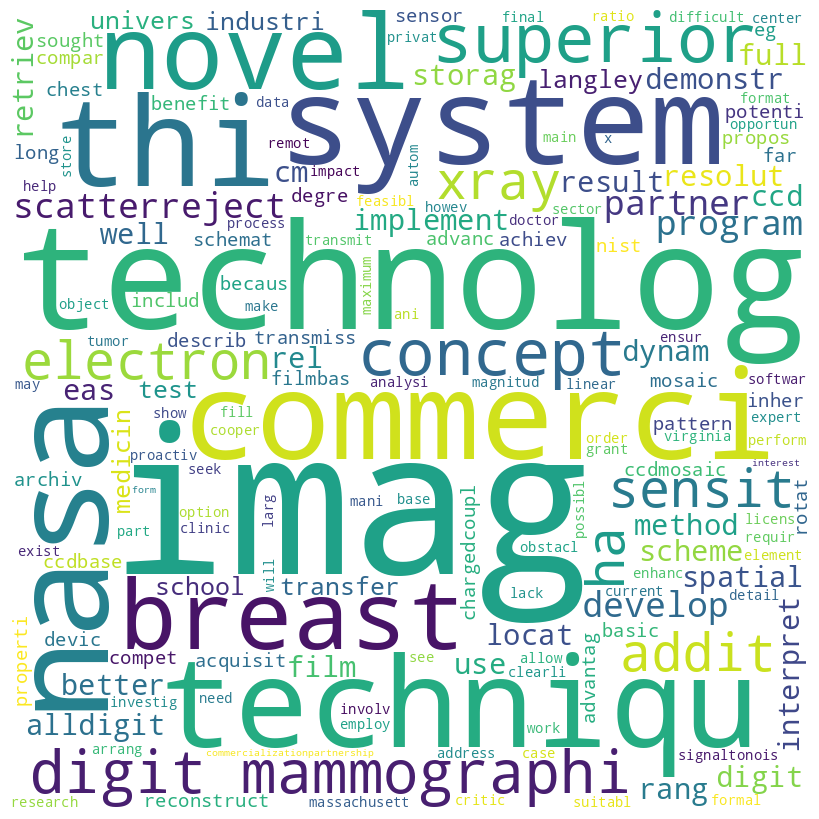

In [ ]:
# join all the words into a single string separated by spaces
text = " ".join(docs_text_stemmed[0])

# create a WordCloud object
wordcloud = WordCloud(width=800, height=800, background_color="white", min_font_size=10, stopwords=None).generate(text)

# display the tag cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

plt.show()

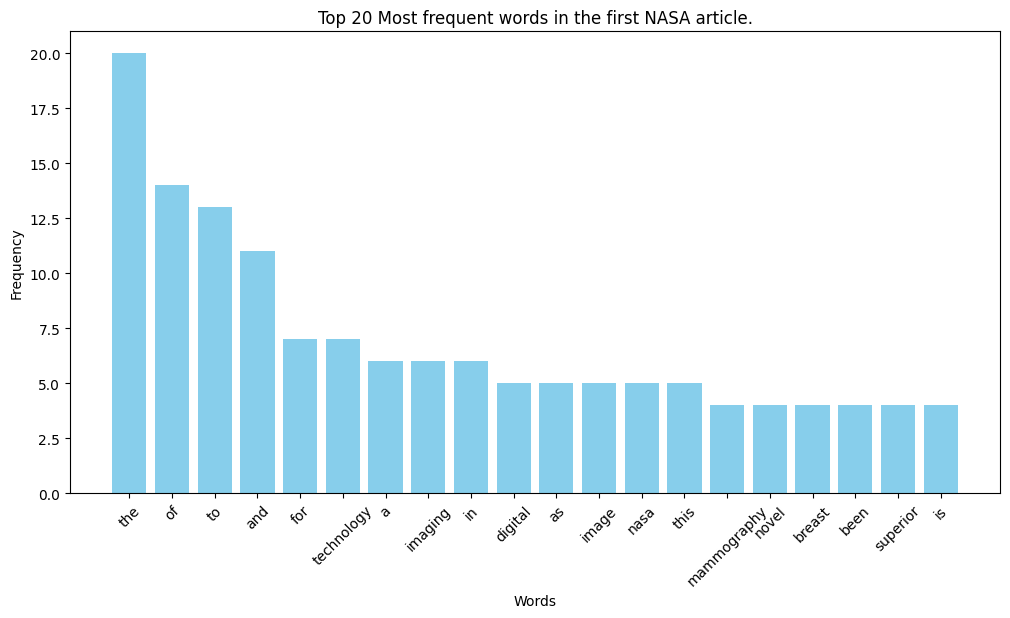

In [ ]:
word_counts = Counter(docs_text_tokenized[0])

# Get the 20 most common words
most_common_words = word_counts.most_common(20)

# Split into words and their frequencies
words, frequencies = zip(*most_common_words)

plt.figure(figsize=(12, 6))
plt.bar(words, frequencies, color='skyblue')
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most frequent words in the first NASA article.")
plt.xticks(rotation=45)
plt.show()


### 3. Compute the <b><i>term frequency</i></b> $tf_{ij}$ and <b><i>tf-idf</i></b> $w_{ij}$ for each document.Choose the top $p$ stems and compare them based on <b><i>term frequency</i></b> and <b><i>tf-idf</i></b> for each document, providing brief comments.

In [ ]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# Compute TF
count_vectorizer = CountVectorizer()
tf_matrix = count_vectorizer.fit_transform(docs_text_stemmed_str)  # (num_docs × num_terms)
tf_df = pd.DataFrame(tf_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

# Compute TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(docs_text_stemmed_str)  # (num_docs × num_terms)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

p = 15  # Number of top stems per document (SEPARATELY)

# Extract top p stems for each document based on TF and TF-IDF
top_stems_per_doc = []

for i in range(len(docs_text_stemmed_str)):
    # Get top p stems based on TF for this document
    top_tf_stems = tf_df.iloc[i].nlargest(p).index.tolist()

    # Get top p stems based on TF-IDF for this document
    top_tfidf_stems = tfidf_df.iloc[i].nlargest(p).index.tolist()

    top_stems_per_doc.append({
        "Document": i,
        "Top TF Stems": top_tf_stems,
        "Top TF-IDF Stems": top_tfidf_stems
    })

top_stems_df = pd.DataFrame(top_stems_per_doc)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

top_stems_df

,Document,Top TF Stems,Top TF-IDF Stems
0,0,"[the, of, imag, to, and, for, technolog, digit, in, nasa, as, commerci, system, techniqu, thi]","[imag, the, digit, of, to, breast, mammographi, superior, and, concept, novel, scatterreject, xray, techniqu, electron]"
1,1,"[process, nasa, the, and, of, resin, high, commerci, develop, powder, ribbon, to, been, composit, for]","[resin, powder, ribbon, solvent, high, process, nasa, the, composit, and, util, cost, cure, novel, prepreg]"
2,2,"[the, of, and, to, in, combust, for, hfca, test, cfc, concentr, pressur, temperatur, use, ha]","[combust, hfca, the, cfc, of, refriger, concentr, test, pressur, and, mixtur, to, temperatur, in, rang]"
3,3,"[the, to, of, devic, support, and, is, thi, use, for, technolog, commerci, an, articl, design]","[support, the, devic, to, of, stiff, articl, weight, motion, rod, and, is, design, connect, spring]"
4,4,"[the, and, for, is, of, mold, cast, use, ceram, in, slip, to, detail, liquid, or]","[mold, cast, slip, the, ceram, liquid, and, shell, for, new, is, of, invest, use, pattern]"
5,5,"[the, control, of, test, for, comput, emi, to, is, assess, upset, electromagnet, langley, nasa, process]","[control, the, emi, comput, test, upset, electromagnet, assess, closedloop, of, for, chamber, dynam, field, clcm]"
6,6,"[and, co, of, catalyst, the, for, oxid, in, to, develop, at, temperatur, commerci, formaldehyd, laser]","[co, catalyst, oxid, and, of, formaldehyd, lowtemperatur, laser, the, nmro, for, at, temperatur, air, in]"
7,7,"[the, and, of, to, model, is, analysi, structur, crack, nonlinear, technolog, use, are, code, commerci]","[model, the, analysi, crack, nonlinear, and, structur, code, of, fractur, global, stag, respons, strength, to]"
8,8,"[and, cure, the, for, resin, to, in, low, composit, ebeam, process, of, thermal, is, or]","[cure, and, resin, ebeam, low, the, composit, thermal, epoxi, cost, resist, for, aor, to, in]"
9,9,"[the, of, to, is, and, banif, hole, blind, commerci, in, nasa, repair, technolog, anchor, anchornut]","[the, banif, hole, blind, repair, anchor, anchornut, rivet, of, to, drill, nut, is, side, and]"


### Comments


Here we notice very visibly the "take over" or dominance of stopwords (the, and, to...) in the TF list, as they frequently appear in sentences. However, in the TF-IDF list, they are fewer and outnumbered by more technical and meaningful terms. This happens because TF-IDF reduces the weight of common words across multiple documents, as they do not contribute to distinguishing the document's content (they are not discriminative). Instead, it emphasizes more distinctive and domain-specific words (laser, diode, emission...).

### 4. Build <b><i>boolean</i></b> and <b><i>vector models</i></b> based on the top $p$ stems, and provide $k$ queries to each IR system. Compare the rankings of the relevant articles.

In [ ]:
def compute_tf(docs):
  count_vectorizer = CountVectorizer()
  tf_matrix = count_vectorizer.fit_transform(docs)  # (num_docs × num_terms)
  tf_df = pd.DataFrame(tf_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

  return count_vectorizer, tf_matrix, tf_df


def compute_tf_idf(docs):
  tfidf_vectorizer = TfidfVectorizer()
  tfidf_matrix = tfidf_vectorizer.fit_transform(docs_text_stemmed_str)  # (num_docs × num_terms)
  tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

  return tfidf_vectorizer, tfidf_matrix, tfidf_df

In [ ]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# TF
count_vectorizer, tf_matrix, tf_df = compute_tf(docs_text_stemmed_str)

# Compute TF-IDF
tfidf_vectorizer, tfidf_matrix, tfidf_df = compute_tf_idf(docs_text_stemmed_str)

# Select the top p stems based on their total term frequency across all documents
p = 15
top_p_stems = tf_df.sum(axis=0).nlargest(p).index.tolist()

# Extract only the top p stems from both TF and TF-IDF matrices
tf_top_p = tf_df[top_p_stems]
tfidf_top_p = tfidf_df[top_p_stems]

# Display the comparison
print("Top {} Stems Based on Term Frequency:".format(p))
print(tf_top_p)

print("\nTop {} Stems Based on TF-IDF:".format(p))
print(tfidf_top_p)


Top 15 Stems Based on Term Frequency:
    the  of  and  to  for  is  in  technolog  nasa  commerci  thi  use  develop  are  with
0    20  14   11  13    7   4   6          7     6         5    5    2        3    1     2
1    10   8    9   6    5   2   3          5    10         6    3    1        6    3     4
2    23  19   13  12    9   6  11          6     5         3    6    7        3    2     3
3    34  16   10  21    7  10   4          7     5         6    8    8        5    4     4
4    27  14   20  10   15  14  10          5     5         6    3   11        5    5     3
5    39  17    5  12   16  11   6          7     7         4    4    7        6    5     3
6    16  24   25  12   15   4  13          7     7         7    3    2       11    5     6
7    26  18   20  13    6  10   5          7     5         6    4    7        2    6     5
8    21   7   33  12   13   6  11          5     5         3    2    1        2    4     5
9    39  14   10  13    5  12   6          6     6  

In [45]:
def build_boolean_model(vocabulary, docs):
  count_vectorizer = CountVectorizer(vocabulary=vocabulary, binary=True)
  boolean_matrix = count_vectorizer.fit_transform(docs)
  boolean_df = pd.DataFrame(boolean_matrix.toarray(), columns=vocabulary)

  return count_vectorizer, boolean_matrix, boolean_df


def build_vector_space_model(vocabulary, docs):
  tfidf_vectorizer = TfidfVectorizer(vocabulary=vocabulary)
  tfidf_matrix = tfidf_vectorizer.fit_transform(docs)
  tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vocabulary)

  return tfidf_vectorizer, tfidf_matrix, tfidf_df


def boolean_query(query, boolean_df):
    query_terms = set(query)
    relevant_docs = []
    for idx, doc_terms in boolean_df.iterrows():
        if query_terms.issubset(doc_terms.index[doc_terms == 1]):
            relevant_docs.append(idx)
    return relevant_docs


def vector_space_query(query, tfidf_df, tfidf_vectorizer):
    query_vec = np.zeros(len(tfidf_df.columns))
    for term in query:
        if term in tfidf_df.columns:
            query_vec[tfidf_df.columns.get_loc(term)] = 1
    query_vec = query_vec.reshape(1, -1)
    similarities = cosine_similarity(query_vec, tfidf_df)
    ranked_docs = np.argsort(similarities[0])[::-1]
    return ranked_docs

In [46]:
# Create a CountVectorizer for the Boolean Model
count_vectorizer, boolean_matrix, boolean_df = build_boolean_model(top_p_stems, docs_text_stemmed_str)

# Create a TfidfVectorizer for the Vector Space Model
tfidf_vectorizer, tfidf_matrix, tfidf_df = build_vector_space_model(top_p_stems, docs_text_stemmed_str)

queries = [
   ["technology", "nasa", "develop", "commercial", "use"],  # Query 1
   ["nasa", "transfert", "develop", "awa"],  # Query 2
   ["develop", "and", "use", "with"],  # Query 3
]
# Preprocess
# queries = tokenize_docs(queries)  #if they weren't already in the form of tokens
# queries = stem(queries)



# Evaluate each query
for i, query in enumerate(queries):
    print(f"Query {i+1}: {query}")

    boolean_results = boolean_query(query, boolean_df)
    print(f"  Boolean Model Retrieved Documents: {boolean_results}")

    vector_space_results = vector_space_query(query, tfidf_df, tfidf_vectorizer)
    print(f"  Vector Space Model Ranked Documents: {vector_space_results}")
    print()

Query 1: ['technology', 'nasa', 'develop', 'commercial', 'use']
  Boolean Model Retrieved Documents: []
  Vector Space Model Ranked Documents: [ 4  3  9 10  7 14  6 12  0  1  2 11  5 13  8]

Query 2: ['nasa', 'transfert', 'develop', 'awa']
  Boolean Model Retrieved Documents: []
  Vector Space Model Ranked Documents: [ 6  9 14 10  1  3  0  4 12  7 11  5  2  8 13]

Query 3: ['develop', 'and', 'use', 'with']
  Boolean Model Retrieved Documents: []
  Vector Space Model Ranked Documents: [ 4  3 10  7  9  6 14 12  2 11  5  0  1 13  8]



In [43]:
# Create a CountVectorizer for the Boolean Model
count_vectorizer, boolean_matrix, boolean_df = build_boolean_model(top_p_stems, docs_text_stemmed_str)


# # queries = ['''
# # An inexpensive and simple means to improve control of helicopters has been
# # developed. During hovering flight in windy conditions, the pilot's ability
# # to maintain heading control is greatly enhanced by the addition of strakes
# # horizontally mounted along the helicopter tail boom. Without the strakes,
# # the tail boom "flies" in the winds from the main rotor and crosswinds which
# # causes the tail rotor to work harder and use up control available to the
# # pilot to maneuver the helicopter. The tail boom strakes act like a fence to
# # the airflow moving over the boom and changes the reactions of the boom in a
# # way to result in more control for the pilot and less power needed for the
# # tail rotor.''',
# #            '''It is now possible to obtain planar Rayleigh scattering data in Mach 6 flow
# # fields. This is due to the rapid technology advances in high power pulsed
# # excimer lasers, gated single intensified charge-couple device (CCD) cameras,
# # and fast frame grabbers. Because very short laser pulses (20 nanoseconds)
# # are used, the flow will be essentially frozen for each data acquisition
# # cycle. This allows snap-shots of the flow field to be taken. These
# # snap-shots can then reveal the extent of the unsteadiness in the flow field.
# # It is also possible to average these snap-shots and obtain a mean
# # quantitative density map of the flow field.''',
# #            '''Development of suspension devices for ground testing spacecraft has resulted
# # in the development of a small compact low stiffness support device. The
# # device can be designed to support weight of an object such that conditions
# # of weightlessness can be emulated at the point where an object is connected
# # to the device.''',
# #            '''kila cuubal mali la deukk aminta bakhoyo yokho''',
# #            '''The project demands lightweight components, a high resolution real-time
# # video image and seamless integration with the magnetic crawler. Zoom
# # capabilities and a high resolution image will allow for highly detailed
# # video images while auto camera functions and a pan & tilt will allow for
# # versatility and easy operation. This combined technology offers a multitude
# # of remote inspection, sensing, mapping and access applications.''',


# ]

queries = [
    ['an', 'inexpens', 'and', 'simpl', 'mean', 'to', 'improv', 'control', 'of', 'helicopt', 'ha', 'been', 'develop', 'dure', 'hover', 'flight', 'in',
     'windi', 'condit', 'the', 'pilot', 'abil', 'to', 'maintain', 'head', 'control', 'is', 'greatli', 'enhanc', 'by', 'the', 'addit', 'of', 'strake', 'horizont',
     'mount', 'along', 'the', 'helicopt', 'tail', 'boom', 'without', 'the', 'strake', 'the', 'tail', 'boom', 'fli', 'in', 'the', 'wind', 'from', 'the', 'main', 'rotor', 'and',
     'crosswind', 'which', 'caus', 'the', 'tail', 'rotor', 'to', 'work', 'harder', 'and', 'use', 'up', 'control', 'avail', 'to', 'the', 'pilot', 'to', 'maneuv', 'the', 'helicopt',
     'the', 'tail', 'boom', 'strake', 'act', 'like', 'a', 'fenc', 'to', 'the', 'airflow', 'move', 'over', 'the', 'boom', 'and', 'chang', 'the', 'reaction', 'of', 'the', 'boom', 'in', 'a',
     'way', 'to', 'result', 'in', 'more', 'control', 'for', 'the', 'pilot', 'and', 'less', 'power', 'need', 'for', 'the', 'tail', 'rotor'],
    ['it', 'is', 'now', 'possibl', 'to', 'obtain', 'planar', 'rayleigh', 'scatter', 'data', 'in', 'mach', 'flow', 'field', 'thi', 'is', 'due', 'to', 'the', 'rapid', 'technolog',
     'advanc', 'in', 'high', 'power', 'puls', 'excim', 'laser', 'gate', 'singl', 'intensifi', 'chargecoupl', 'devic', 'ccd', 'camera', 'and', 'fast', 'frame', 'grabber', 'becaus',
     'veri', 'short', 'laser', 'puls', 'nanosecond', 'are', 'use', 'the', 'flow', 'will', 'be', 'essenti', 'frozen', 'for', 'each', 'data', 'acquisit', 'cycl', 'thi', 'allow', 'snapshot',
     'of', 'the', 'flow', 'field', 'to', 'be', 'taken', 'these', 'snapshot', 'can', 'then', 'reveal', 'the', 'extent', 'of', 'the', 'unsteadi', 'in', 'the', 'flow', 'field', 'it', 'is',
     'also', 'possibl', 'to', 'averag', 'these', 'snapshot', 'and', 'obtain', 'a', 'mean', 'quantit', 'densiti', 'map', 'of', 'the', 'flow', 'field'],
    ['kila', 'cuubal', 'mali', 'la', 'deukk', 'aminta', 'bakhoyo', 'yokho'],
    ['the', 'project', 'demand', 'lightweight', 'compon', 'a', 'high', 'resolut', 'realtim', 'video', 'imag', 'and', 'seamless', 'integr', 'with', 'the',
     'magnet', 'crawler', 'zoom', 'capabl', 'and', 'a', 'high', 'resolut', 'imag', 'will', 'allow', 'for', 'highli', 'detail', 'video', 'imag', 'while', 'auto',
     'camera', 'function', 'and', 'a', 'pan', 'tilt', 'will', 'allow', 'for', 'versatil', 'and', 'easi', 'oper', 'thi', 'combin', 'technolog', 'offer', 'a', 'multitud',
     'of', 'remot', 'inspect', 'sens', 'map', 'and', 'access', 'applic']






]
# Preprocess
# queries = tokenize_docs(queries)
# queries = [flatten(doc) for doc in queries]
# queries = stem(queries)
# print(queries[0])


# Evaluate each query
for i, query in enumerate(queries):
    print(f"Query {i+1}: {query}")

    boolean_results = boolean_query(query, boolean_df)
    print(f"  Boolean Model Retrieved Documents: {boolean_results}")


Query 1: ['an', 'inexpens', 'and', 'simpl', 'mean', 'to', 'improv', 'control', 'of', 'helicopt', 'ha', 'been', 'develop', 'dure', 'hover', 'flight', 'in', 'windi', 'condit', 'the', 'pilot', 'abil', 'to', 'maintain', 'head', 'control', 'is', 'greatli', 'enhanc', 'by', 'the', 'addit', 'of', 'strake', 'horizont', 'mount', 'along', 'the', 'helicopt', 'tail', 'boom', 'without', 'the', 'strake', 'the', 'tail', 'boom', 'fli', 'in', 'the', 'wind', 'from', 'the', 'main', 'rotor', 'and', 'crosswind', 'which', 'caus', 'the', 'tail', 'rotor', 'to', 'work', 'harder', 'and', 'use', 'up', 'control', 'avail', 'to', 'the', 'pilot', 'to', 'maneuv', 'the', 'helicopt', 'the', 'tail', 'boom', 'strake', 'act', 'like', 'a', 'fenc', 'to', 'the', 'airflow', 'move', 'over', 'the', 'boom', 'and', 'chang', 'the', 'reaction', 'of', 'the', 'boom', 'in', 'a', 'way', 'to', 'result', 'in', 'more', 'control', 'for', 'the', 'pilot', 'and', 'less', 'power', 'need', 'for', 'the', 'tail', 'rotor']
  Boolean Model Retrieved

### Comparison of ranking of relevant articles

For the Boolean model, documents are ranked based on the **presence or absence** of query terms. If all query terms exist in a document, it is retrieved; otherwise, it is not. As we notice, when a query (Query 2, 3) includes a word **not present** in the corpus (a name awa or an uncommon term), **no documents are retrieved** because the Boolean model strictly requires matches. On the other hand, if the query terms are found in the corpus, documents are retrieved regardless of their frequency or importance in the text. This makes the Boolean model ideal for **precise filtering** but too rigid when dealing with partial matches or synonyms.  

In contrast, the Vector Space Model ranks documents based on **similarity** rather than strict inclusion. Even if **some query terms are missing**, the model still returns a ranked list of documents based on how closely they relate to the query. This is useful when no exact matches exist, as seen in Queries 2 and 3, where Boolean retrieval failed but VSM still provided ranked results. Also, VSM considers term frequency and importance (TF-IDF weighting), ensuring that more **relevant documents appear higher** in the ranking.

### Remove Stop Words

In [ ]:
print([len(doc) for doc in docs_text_tokenized], end=' ')

[401, 306, 473, 448, 535, 559, 560, 462, 667, 363, 331, 529, 270, 559, 326] 

In [ ]:
docs_text_tokenized = [[w for w in doc if w not in stop_words] for doc in docs_text_tokenized]

In [ ]:
print([len(doc) for doc in docs_text_tokenized], end=' ')

[262, 214, 294, 273, 330, 371, 355, 305, 485, 217, 227, 372, 167, 356, 204] 

### Stemming

In [ ]:
docs_text_stemmed = stem(docs_text_tokenized)

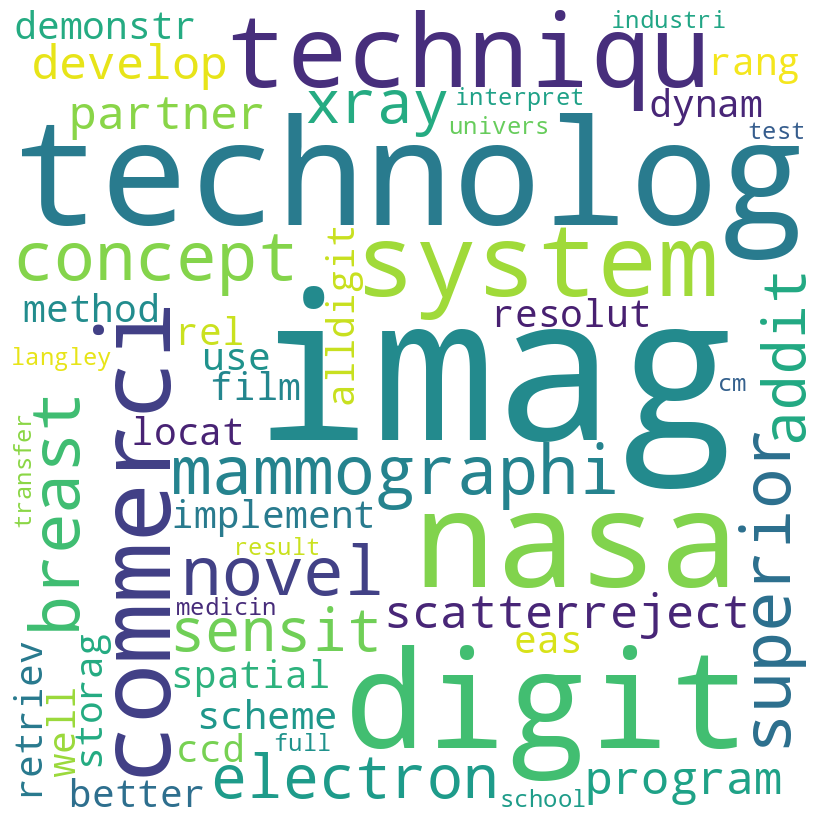

In [ ]:
# join all the words into a single string separated by spaces
text = " ".join(docs_text_stemmed[0])

# count word frequencies
word_counts = Counter(text.split())

# get the top 50 most frequent words
top_50 = dict(word_counts.most_common(50))

# create a WordCloud object using only the top 50 words
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    min_font_size=10,
    stopwords=None
).generate_from_frequencies(top_50)

# display the tag cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

# show the tag cloud
plt.show()

In [ ]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# Compute Term Frequency (TF)
count_vectorizer, tf_matrix, tf_df = compute_tf(docs_text_stemmed_str)

# Compute TF-IDF
tfidf_vectorizer, tfidf_matrix, tfidf_df = compute_tf_idf(docs_text_stemmed_str)

p = 15  # Number of top stems per document

# Extract top p stems for each document based on TF and TF-IDF
top_stems_per_doc = []

for i in range(len(docs_text_stemmed_str)):
    # Get top p stems based on TF for this document
    top_tf_stems = tf_df.iloc[i].nlargest(p).index.tolist()

    # Get top p stems based on TF-IDF for this document
    top_tfidf_stems = tfidf_df.iloc[i].nlargest(p).index.tolist()

    top_stems_per_doc.append({
        "Document": i,
        "Top TF Stems": top_tf_stems,
        "Top TF-IDF Stems": top_tfidf_stems
    })

# Convert to DataFrame for better visualization
top_stems_df = pd.DataFrame(top_stems_per_doc)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

top_stems_df

,Document,Top TF Stems,Top TF-IDF Stems
0,0,"[imag, technolog, digit, nasa, commerci, system, techniqu, breast, concept, mammographi, novel, superior, addit, develop, electron]","[imag, digit, breast, mammographi, superior, concept, novel, scatterreject, xray, techniqu, electron, technolog, system, sensit, alldigit]"
1,1,"[process, nasa, resin, high, commerci, develop, powder, ribbon, composit, solvent, system, technolog, util, cost, cure]","[resin, powder, ribbon, solvent, high, process, nasa, composit, util, cost, cure, novel, prepreg, line, system]"
2,2,"[combust, hfca, test, cfc, concentr, pressur, temperatur, use, refriger, technolog, condit, nasa, rang, ga, langley]","[combust, hfca, cfc, refriger, concentr, test, pressur, mixtur, temperatur, rang, condit, ga, databas, ignit, tdt]"
3,3,"[devic, support, use, technolog, commerci, articl, design, develop, nasa, stiff, weight, motion, object, rod, air]","[support, devic, stiff, articl, weight, motion, rod, design, connect, spring, vertic, air, coupl, less, suspens]"
4,4,"[mold, cast, use, ceram, slip, detail, liquid, commerci, new, shell, develop, nasa, technolog, invest, materi]","[mold, cast, slip, ceram, liquid, shell, new, invest, use, pattern, method, remov, absorb, easili, particl]"
5,5,"[control, test, comput, emi, assess, upset, electromagnet, langley, nasa, process, technolog, use, closedloop, develop, dynam]","[control, emi, comput, test, upset, electromagnet, assess, closedloop, chamber, dynam, field, clcm, fault, interfer, oper]"
6,6,"[co, catalyst, oxid, develop, temperatur, commerci, formaldehyd, laser, nasa, technolog, lowtemperatur, air, nmro, applic, regener]","[co, catalyst, oxid, formaldehyd, lowtemperatur, laser, nmro, temperatur, air, regener, develop, remov, room, typic, corp]"
7,7,"[model, analysi, structur, crack, nonlinear, technolog, use, code, commerci, fractur, global, nasa, respons, stag, strength]","[model, analysi, crack, nonlinear, structur, code, fractur, global, stag, respons, strength, analys, francd, fuselag, residu]"
8,8,"[cure, resin, low, composit, ebeam, process, thermal, cost, epoxi, nasa, resist, structur, technolog, aor, base]","[cure, resin, ebeam, low, composit, thermal, epoxi, cost, resist, aor, structur, mold, seri, effici, aeropla]"
9,9,"[banif, hole, blind, commerci, nasa, repair, technolog, anchor, anchornut, rivet, compon, develop, drill, nut, side]","[banif, hole, blind, repair, anchor, anchornut, rivet, drill, nut, side, blindanchornutinstallationfixtur, clearanc, compon, fasten, place]"


### Comments
After the removal of stopwords, we see more meaningful terms relevant to the document's content, making their way up in the top 15 stems. This make the TF and TF-IDF lists more similar, as both would focus on important domain-specific words. However, TF-IDF would still provide better differentiation by emphasizing terms that are less frequent across multiple documents but important to specific ones. As a result, removing stopwords helps reduce "noise" in the analysis.

In [ ]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# Compute TF
count_vectorizer, tf_matrix, tf_df = compute_tf(docs_text_stemmed_str)

# Compute TF-IDF
tfidf_vectorizer, tfidf_matrix, tfidf_df = compute_tf_idf(docs_text_stemmed_str)

# Select the top p stems based on their total term frequency across all documents
p = 15
top_p_stems = tf_df.sum(axis=0).nlargest(p).index.tolist()

# Extract only the top p stems from both TF and TF-IDF matrices
tf_top_p = tf_df[top_p_stems]
tfidf_top_p = tfidf_df[top_p_stems]

print("Top {} Stems Based on Term Frequency:".format(p))
print(tf_top_p)

print("\nTop {} Stems Based on TF-IDF:".format(p))
print(tfidf_top_p)

Top 15 Stems Based on Term Frequency:
    technolog  nasa  commerci  use  develop  test  program  process  temperatur  langley  high  \
0           7     6         5    2        3     2        3        1           0        2     0   
1           5    10         6    1        6     0        3       11           3        1     7   
2           6     5         3    7        3     9        3        2           7        4     0   
3           7     5         6    8        5     3        3        1           0        2     0   
4           5     5         6   11        5     0        3        1           3        1     3   
5           7     7         4    7        6    17        3        7           0        7     0   
6           7     7         7    2       11     1        3        1           8        3     1   
7           7     5         6    7        2     0        3        1           0        3     0   
8           5     5         3    1        2     0        2        8           2 

### Simple querying

In [ ]:
# Create a CountVectorizer for the Boolean Model
count_vectorizer, boolean_matrix, boolean_df = build_boolean_model(top_p_stems, docs_text_stemmed_str)

# Create a TfidfVectorizer for the Vector Space Model
tfidf_vectorizer, tfidf_matrix, tfidf_df = build_vector_space_model(top_p_stems, docs_text_stemmed_str)

queries = [
   ["technology", "nasa", "develop", "commercial", "use"],
   ["nasa", "transfert", "develop", "awa"],
   ["develop", "and", "use", "with"],
]
# Preprocess
# queries = tokenize_docs(queries)  #if they weren't already in the form of tokens
queries = stem(queries)

# Evaluate each query
for i, query in enumerate(queries):
    print(f"Query {i+1}: {query}")

    boolean_results = boolean_query(query, boolean_df)
    print(f"  Boolean Model Retrieved Documents: {boolean_results}")

    vector_space_results = vector_space_query(query, tfidf_df, tfidf_vectorizer)
    print(f"  Vector Space Model Ranked Documents: {vector_space_results}")
    print()

Query 1: ['technolog', 'nasa', 'develop', 'commerci', 'use']
  Boolean Model Retrieved Documents: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  Vector Space Model Ranked Documents: [ 9 10  3  7 14  4 12  0 11  6  1  2  5 13  8]

Query 2: ['nasa', 'transfert', 'develop', 'awa']
  Boolean Model Retrieved Documents: []
  Vector Space Model Ranked Documents: [ 6  9 14 10  1  3  0  4 12  7 11  5  2  8 13]

Query 3: ['develop', 'and', 'use', 'with']
  Boolean Model Retrieved Documents: []
  Vector Space Model Ranked Documents: [ 4  3 10  7  9  6 14 12  2 11  5  0  1 13  8]



### Comments
The previous analaysis holds here too, just without the stopwords, so "cleaner" corpus. As such, the retrieval is much more menaingful and focused.

### Final remarks and conclusions.

Overall, the Boolean model works well for exact-match searches, making it useful for filtering documents based on specific terms. However, it can be too strict, failing to retrieve anything if a query contains words not present in the corpus. In contrast, the VSM is much more flexible, ranking documents based on their similarity to the query, even if some words are missing. Removing stopwords improves both models by eliminating common, non-informative words, and that makes searches more focused and rankings more meaningful. While the Boolean model is great for precise filtering, VSM is better for handling variations in terminology and ranking results in an efficient way.